Dataset: sns.load_dataset('flights') 
Goal: Take raw historical flight data and polish it into a presentation-ready graphic.
Themes & Contexts: Apply sns.set_style('whitegrid') to give it a clean background, and sns.set_context('talk') to automatically scale up the fonts for a presentation slide.
Color Palettes: Pivot the dataset into a matrix (months vs. years) and plot a heatmap. Use sns.color_palette("Blues", as_cmap=True) so the colors intuitively map from light (few passengers) to dark (many passengers).
Advanced Matplotlib Formatting: Plot a line chart of average passengers per year.
Rotate the X-axis labels (years) by 45 degrees so they are perfectly legible.
Use ax.set_ylim(0, 500) to force the Y-axis to start at zero instead of floating.
Use ax.annotate() to draw an arrow pointing to the year 1960 with the text: "Introduction of Commercial Jets".
Exporting: Run plt.savefig('executive_flight_report.png', dpi=300, bbox_inches='tight') to save the final, high-resolution masterpiece to their computer.Explain each of the graphs in details(both Khmer and English)

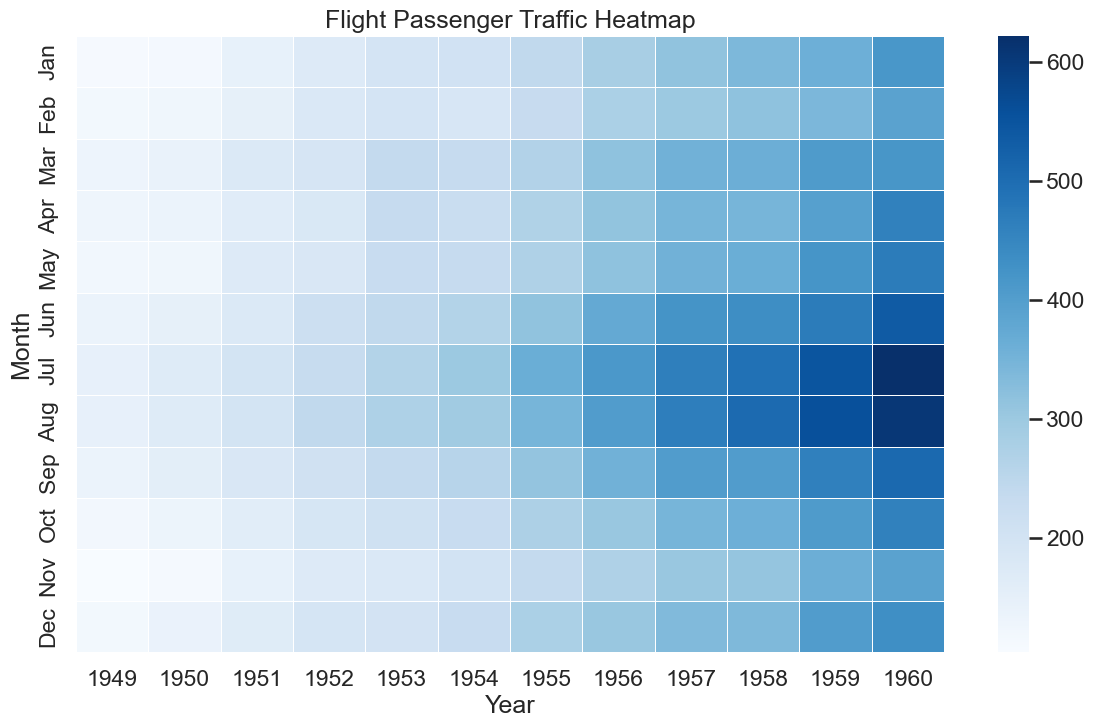

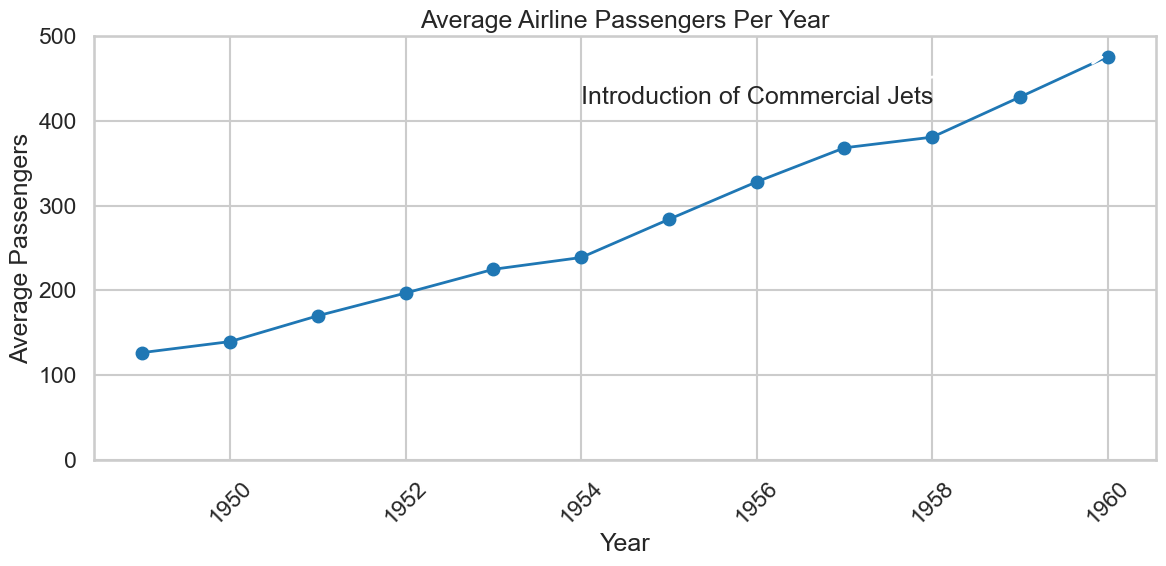

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
flights = sns.load_dataset('flights')
sns.set_style('whitegrid')
sns.set_context('talk')
flights_pivot = flights.pivot(
    index='month',
    columns='year',
    values='passengers'
)
plt.figure(figsize=(14, 8))
sns.heatmap(
    flights_pivot,
    cmap=sns.color_palette("Blues", as_cmap=True),
    linewidths=0.5
)
plt.title('Flight Passenger Traffic Heatmap')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()
avg_passengers = flights.groupby('year')['passengers'].mean()
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    avg_passengers.index,
    avg_passengers.values,
    marker='o',
    linewidth=2
)
ax.set_title('Average Airline Passengers Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Average Passengers')
plt.xticks(rotation=45)
ax.set_ylim(0, 500)
ax.annotate(
    'Introduction of Commercial Jets',
    xy=(1960, avg_passengers.loc[1960]),
    xytext=(1954, 420),
    arrowprops=dict(arrowstyle='->', lw=2)
)
plt.tight_layout()
plt.savefig(
    'executive_flight_report.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()